In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [3]:
df = pd.read_csv("../dataset/cleaned_transactions.csv")

In [4]:
df["fraud_flag"].sum()
fraud_rate = (
    df["fraud_flag"].sum() /
    len(df)
) * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 0.19%


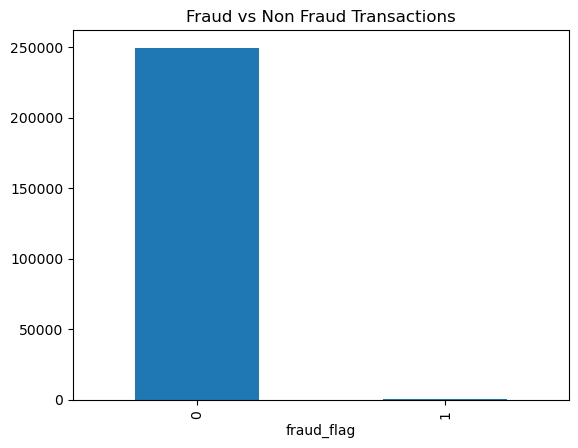

In [5]:
df["fraud_flag"].value_counts()
df["fraud_flag"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud vs Non Fraud Transactions")
plt.show()

In [6]:
fraud_amount = (
    df.groupby("fraud_flag")["amount_inr"]
      .sum()
)

fraud_amount

fraud_flag
0    327219378
1       719631
Name: amount_inr, dtype: int64

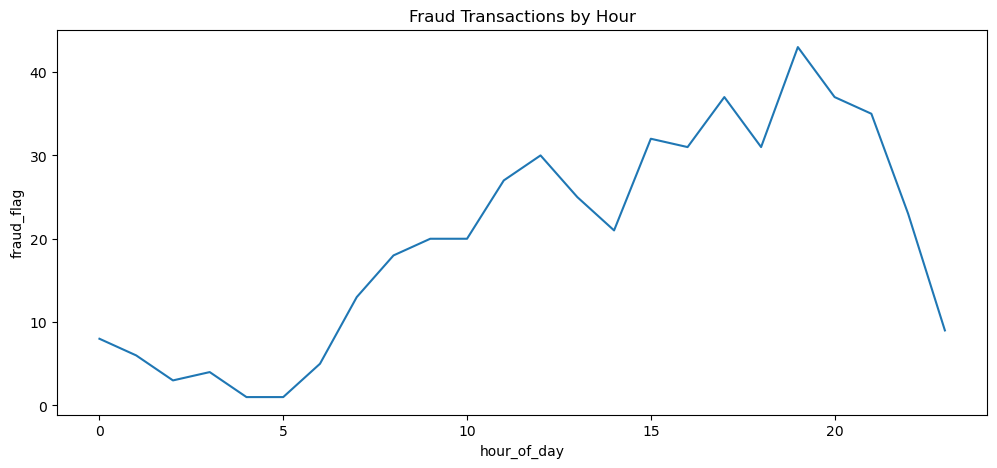

In [7]:
fraud_hour = (
    df.groupby("hour_of_day")["fraud_flag"]
      .sum()
      .reset_index()
)
plt.figure(figsize=(12,5))

sns.lineplot(
    data=fraud_hour,
    x="hour_of_day",
    y="fraud_flag"
)

plt.title("Fraud Transactions by Hour")
plt.show()


In [8]:
fraud_state = (
    df.groupby("sender_state")["fraud_flag"]
      .sum()
      .reset_index()
      .sort_values(
          "fraud_flag",
          ascending=False
      )
)

fraud_state.head(10)

,sender_state,fraud_flag
4,Maharashtra,71
3,Karnataka,69
8,Uttar Pradesh,52
1,Delhi,50
5,Rajasthan,46
2,Gujarat,43
6,Tamil Nadu,40
7,Telangana,39
0,Andhra Pradesh,35
9,West Bengal,35


In [9]:
fraud_device = (
    df.groupby("device_type")["fraud_flag"]
      .sum()
      .reset_index()
      .sort_values(
          "fraud_flag",
          ascending=False
      )
)

fraud_device

,device_type,fraud_flag
0,Android,364
2,iOS,90
1,Web,26


In [10]:
fraud_network = (
    df.groupby("network_type")["fraud_flag"]
      .sum()
      .reset_index()
)

fraud_network

,network_type,fraud_flag
0,3G,24
1,4G,282
2,5G,115
3,WiFi,59


In [11]:
fraud_category = (
    df.groupby("merchant_category")["fraud_flag"]
      .sum()
      .reset_index()
      .sort_values(
          "fraud_flag",
          ascending=False
      )
)

fraud_category.head(10)

,merchant_category,fraud_flag
4,Grocery,94
2,Food,73
7,Shopping,62
6,Other,50
3,Fuel,48
8,Transport,43
1,Entertainment,40
9,Utilities,33
5,Healthcare,21
0,Education,16


In [12]:
fraud_category = (
    df.groupby("merchant_category")["fraud_flag"]
      .sum()
      .reset_index()
      .sort_values(
          "fraud_flag",
          ascending=False
      )
)

fraud_category.head(10)

,merchant_category,fraud_flag
4,Grocery,94
2,Food,73
7,Shopping,62
6,Other,50
3,Fuel,48
8,Transport,43
1,Entertainment,40
9,Utilities,33
5,Healthcare,21
0,Education,16


In [13]:
failed_txns = df[
    df["transaction_status"] == "Failed"
]
len(failed_txns)
failure_rate = (
    len(failed_txns) /
    len(df)
) * 100

print(f"Failure Rate: {failure_rate:.2f}%")

Failure Rate: 0.00%


In [14]:
failed_hour = (
    failed_txns.groupby("hour_of_day")
    .size()
    .reset_index(name="failed_count")
)

failed_hour.head()

,hour_of_day,failed_count


In [15]:
failed_bank = (
    failed_txns.groupby("sender_bank")
    .size()
    .reset_index(name="failed_count")
    .sort_values(
        "failed_count",
        ascending=False
    )
)

failed_bank.head(10)

,sender_bank,failed_count


In [16]:
threshold = (
    df["amount_inr"]
      .quantile(0.95)
)

threshold

np.float64(4687.049999999988)

In [17]:
high_amount_txns = df[
    df["amount_inr"] > threshold
]

high_amount_txns.head()
len(high_amount_txns)

12500

In [18]:
night_txns = df[
    (df["hour_of_day"] >= 23)
    |
    (df["hour_of_day"] <= 4)
]
len(night_txns)

15695

In [19]:
len(night_txns)
(
    night_txns["fraud_flag"].sum()
    /
    len(night_txns)
) * 100

np.float64(0.19751513220770947)

In [20]:
features = df[
    [
        "amount_inr",
        "hour_of_day"
    ]
]
model = IsolationForest(
    contamination=0.02,
    random_state=42
)

model.fit(features)

,n_estimators,100
,max_samples,'auto'
,contamination,0.02
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [21]:
df["anomaly"] = model.predict(
    features
)

In [22]:
df["anomaly"] = (
    df["anomaly"] == -1
).astype(int)

In [23]:
df["anomaly"].value_counts()

anomaly
0    245000
1      5000
Name: count, dtype: int64

In [24]:
#anomaly
anomalies = df[
    df["anomaly"] == 1
]
len(anomalies)
anomalies.head()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,year,month,month_name,day,anomaly
79,TXN0000000080,2024-11-08 20:26:51,P2M,Utilities,8335,SUCCESS,46-55,46-55,West Bengal,Axis,...,4G,0,20,Friday,0,2024,11,November,8,1
159,TXN0000000160,2024-02-16 18:51:24,Bill Payment,Shopping,9619,SUCCESS,18-25,18-25,Maharashtra,SBI,...,4G,0,18,Friday,0,2024,2,February,16,1
165,TXN0000000166,2024-10-29 04:05:56,P2P,Shopping,9228,SUCCESS,18-25,18-25,West Bengal,SBI,...,WiFi,0,4,Tuesday,0,2024,10,October,29,1
199,TXN0000000200,2024-03-06 00:47:23,Bill Payment,Entertainment,1659,FAILED,36-45,18-25,Tamil Nadu,SBI,...,4G,0,0,Wednesday,0,2024,3,March,6,1
288,TXN0000000289,2024-06-05 23:20:06,P2M,Shopping,5634,SUCCESS,26-35,26-35,Maharashtra,Axis,...,4G,0,23,Wednesday,0,2024,6,June,5,1


In [25]:
pd.crosstab(
    df["fraud_flag"],
    df["anomaly"]
)

anomaly,0,1
fraud_flag,,
0,244537,4983
1,463,17


In [26]:
df["risk_score"] = 0
df.loc[
    df["amount_inr"] > threshold,
    "risk_score"
] += 30
df.loc[
    (
        (df["hour_of_day"] >= 23)
        |
        (df["hour_of_day"] <= 4)
    ),
    "risk_score"
] += 20
df.loc[
    df["transaction_status"] == "Failed",
    "risk_score"
] += 25
df.loc[
    df["anomaly"] == 1,
    "risk_score"
] += 25

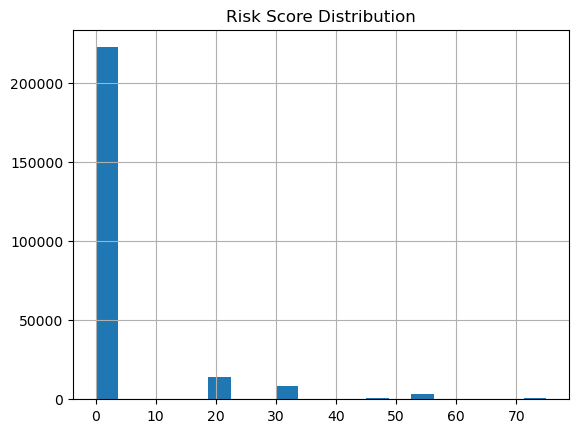

In [27]:
high_risk = df[
    df["risk_score"] >= 50
]
high_risk.head()
df["risk_score"].hist(
    bins=20
)

plt.title("Risk Score Distribution")
plt.show()






In [28]:
anomalies.to_csv(
    "../dataset/anomaly_transactions.csv",
    index=False
)
df.to_csv(
    "../dataset/risk_analysis.csv",
    index=False
)